# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Rafa Rizki Aira Swala | 5054251017 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [33]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

In [34]:
# Load dataset
df = pd.read_csv('bankruptcy.csv')

# Tampilkan 5 baris pertama
print("===== 5 Baris Pertama =====")
display(df.head())

# Cek ukuran dataset
print(f"\n===== Ukuran Dataset =====")
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

# Cek tipe data & info
print("\n===== Info Dataset =====")
print(df.info())

# Statistik deskriptif
print("\n===== Statistik Deskriptif =====")
display(df.describe().T)

===== 5 Baris Pertama =====


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068


===== Ukuran Dataset =====
Jumlah baris : 6819
Jumlah kolom : 96

===== Info Dataset =====
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Ra

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


In [35]:
# Cek jumlah missing value per kolom
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})

# Tampilkan hanya kolom yang punya missing value
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    by='Missing Count', ascending=False
)

print("===== Missing Value =====")
if missing_df.empty:
    print("Tidak ada missing value pada dataset ✅")
else:
    display(missing_df)

# Cek data duplikat
print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

===== Missing Value =====
Tidak ada missing value pada dataset ✅

Jumlah baris duplikat: 0


Nama kolom target: Bankrupt?

===== Distribusi Kelas Target =====
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Proporsi (%) :
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


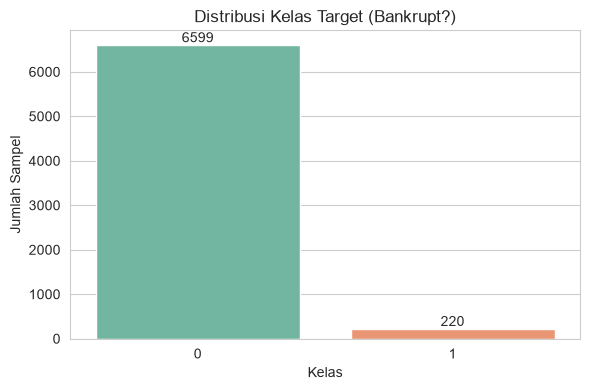

In [36]:
# Cek nama kolom target
target_col = df.columns[0]   # 'Bankrupt?' adalah kolom pertama
print(f"Nama kolom target: {target_col}")

# Distribusi kelas target
print("\n===== Distribusi Kelas Target =====")
print(df[target_col].value_counts())
print("\nProporsi (%) :")
print(df[target_col].value_counts(normalize=True) * 100)

# Bar plot distribusi target
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=target_col, data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Bankrupt?)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

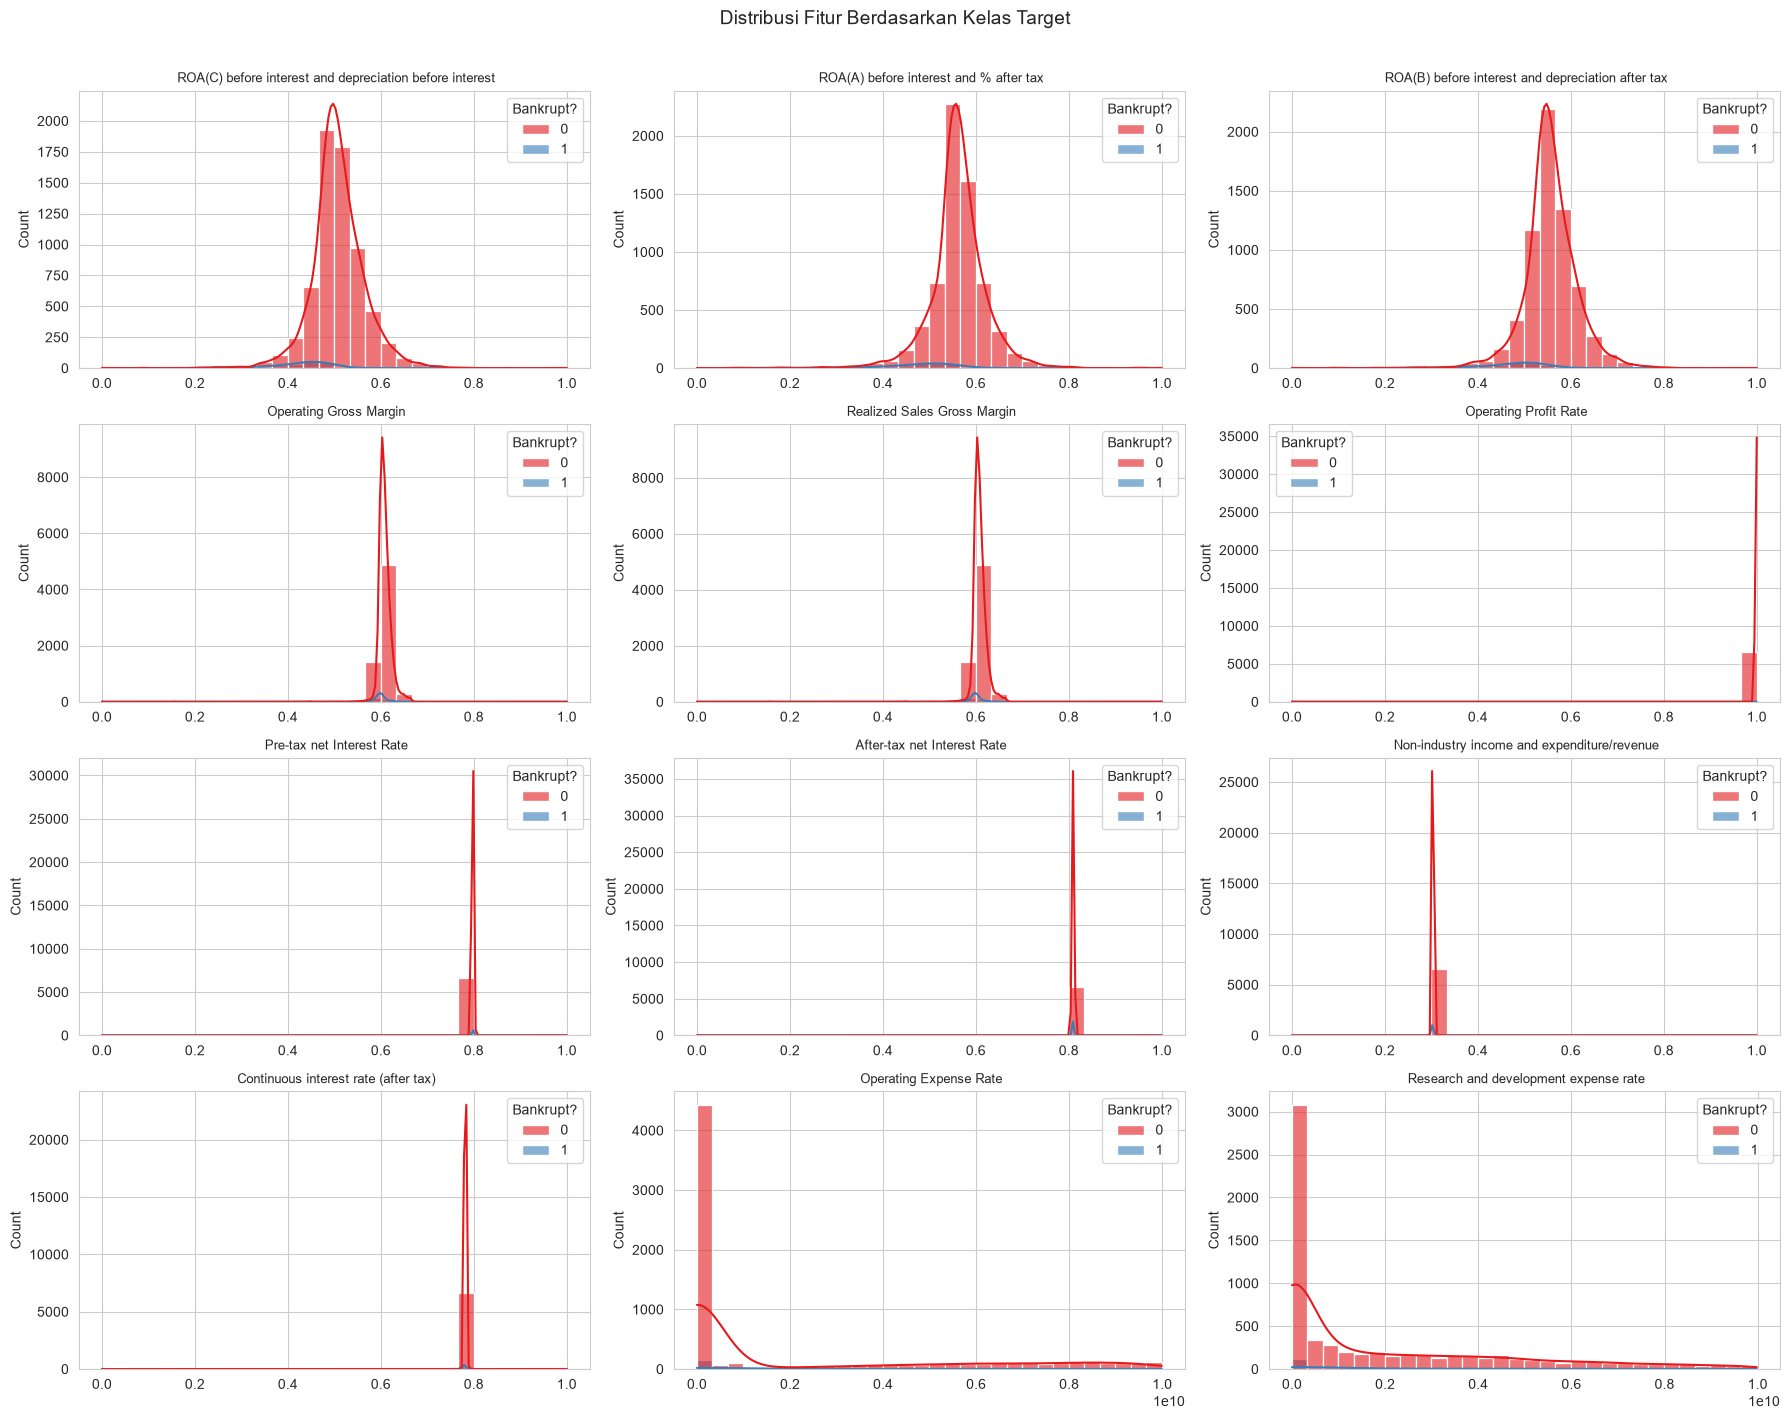

In [37]:
# Ambil fitur numerik (semua kolom kecuali target)
feature_cols = [c for c in df.columns if c != target_col]

# Pilih beberapa fitur pertama untuk divisualisasikan
# (tidak mungkin plot 95 fitur sekaligus)
n_show = 12
selected_features = feature_cols[:n_show]

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    sns.histplot(
        data=df, x=col, hue=target_col,
        kde=True, ax=axes[i], palette='Set1',
        alpha=0.6, bins=30
    )
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Distribusi Fitur Berdasarkan Kelas Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

===== Top 15 Fitur dengan Korelasi Tertinggi terhadap Target =====
Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Debt ratio %                                               0.250161
Persistent EPS in the Last Four Seasons                   -0.219560
Retained Earnings to Total Assets                         -0.217779
Net profit before tax/Paid-in capital                     -0.207857
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Current Liability to Assets                                0.194494
Working Capital to Total Assets                           -0.193083
Net Income to Stockholder's Equity                        -0.180987
Borrowing dependency                             

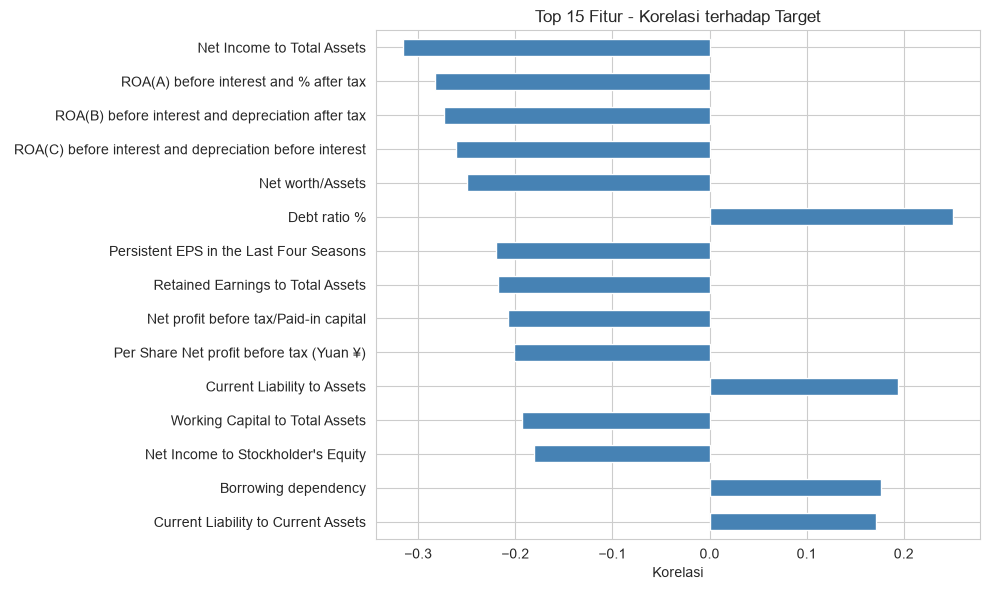

In [38]:
# Korelasi setiap fitur terhadap target
corr_target = df.corr(numeric_only=True)[target_col].drop(target_col)
corr_target = corr_target.sort_values(key=abs, ascending=False)

print("===== Top 15 Fitur dengan Korelasi Tertinggi terhadap Target =====")
print(corr_target.head(15))

# Bar plot top 15 korelasi
plt.figure(figsize=(10, 6))
corr_target.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Fitur - Korelasi terhadap Target')
plt.xlabel('Korelasi')
plt.tight_layout()
plt.show()

In [39]:
# Cek fitur dengan nilai konstan (variance = 0)
const_cols = [c for c in feature_cols if df[c].nunique() <= 1]
print(f"Fitur konstan (nunique <= 1): {const_cols if const_cols else 'Tidak ada'}")

# Cek fitur yang hampir konstan (>99% nilai sama)
near_const = []
for c in feature_cols:
    top_freq = df[c].value_counts(normalize=True).iloc[0]
    if top_freq > 0.99:
        near_const.append((c, round(top_freq * 100, 2)))

print(f"\nFitur hampir konstan (>99% satu nilai):")
for c, p in near_const:
    print(f"  - {c}: {p}%")

Fitur konstan (nunique <= 1): [' Net Income Flag']

Fitur hampir konstan (>99% satu nilai):
  -  Liability-Assets Flag: 99.88%
  -  Net Income Flag: 100.0%


##  Kesimpulan EDA

1. **Ukuran dataset**: ... baris × ... kolom.
2. **Missing value**: (ada / tidak ada) — perlu ditangani pada tahap preprocessing.
3. **Distribusi target**: Dataset (imbalanced / balanced) → kelas 0 = ...%, kelas 1 = ...%.
4. **Korelasi fitur**: Fitur yang paling berkorelasi dengan target adalah ... 
5. **Fitur konstan**: (ada / tidak ada) — kalau ada, akan dibuang pada preprocessing.

# 2. Preprocessing

In [40]:
# Cek kembali missing value
print("Total missing value:", df.isnull().sum().sum())

# Strategi: isi dengan median untuk fitur numerik
# (median lebih robust terhadap outlier dibanding mean)
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing value telah diisi dengan median ✅")
else:
    print("Tidak ada missing value, skip handling ✅")

# Verifikasi
print("Sisa missing value:", df.isnull().sum().sum())

Total missing value: 0
Tidak ada missing value, skip handling ✅
Sisa missing value: 0


In [41]:
# Cek fitur kategorikal
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col]

print(f"Fitur kategorikal: {cat_cols}")

if len(cat_cols) > 0:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print(f"Shape setelah One-Hot Encoding: {df.shape}")
else:
    print("Tidak ada fitur kategorikal ✅")
    print("(Decision Tree memang butuh input numerik di sklearn)")

Fitur kategorikal: []
Tidak ada fitur kategorikal ✅
(Decision Tree memang butuh input numerik di sklearn)


In [42]:
# Pisahkan fitur dan target
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nDistribusi y:\n{y.value_counts()}")

Shape X: (6819, 95)
Shape y: (6819,)

Distribusi y:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(5455, 95) (1364, 95) (5455,) (1364,)


In [44]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_gini.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [45]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [46]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [47]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [48]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
depth_values = [1, 2, 3, 5, 10, None]
models_by_depth = {}

for d in depth_values:
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        random_state=42
    )
    model.fit(X_train, y_train)
    models_by_depth[d] = model

In [49]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
depth_results = []

for d, model in models_by_depth.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    depth_results.append({
        'max_depth': d,
        'train_acc': train_acc,
        'test_acc' : test_acc
    })

df_depth = pd.DataFrame(depth_results)
df_depth

,max_depth,train_acc,test_acc
0,1.0,0.967736,0.967742
1,2.0,0.969936,0.969941
2,3.0,0.972319,0.969941
3,5.0,0.977452,0.968475
4,10.0,0.994684,0.960411
5,NaN,1.000000,0.961144


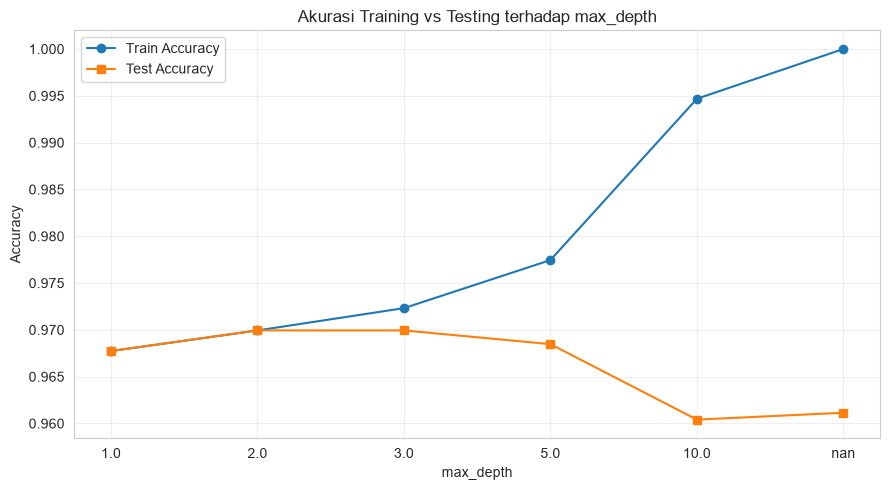

In [50]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
x_labels = [str(d) if d is not None else 'None' for d in df_depth['max_depth']]

plt.figure(figsize=(9, 5))
plt.plot(x_labels, df_depth['train_acc'], marker='o', label='Train Accuracy')
plt.plot(x_labels, df_depth['test_acc'],  marker='s', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Akurasi Training vs Testing terhadap max_depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [51]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def hitung_metrik(y_true, y_pred, nama_model):
    return {
        'Model'    : nama_model,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

df_metrik = pd.DataFrame([
    hitung_metrik(y_test, y_pred_gini,    'Decision Tree (Gini)'),
    hitung_metrik(y_test, y_pred_entropy, 'Decision Tree (Entropy)'),
])

df_metrik

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Gini),0.9611,0.4000,0.4091,0.4045
1,Decision Tree (Entropy),0.9641,0.4359,0.3864,0.4096


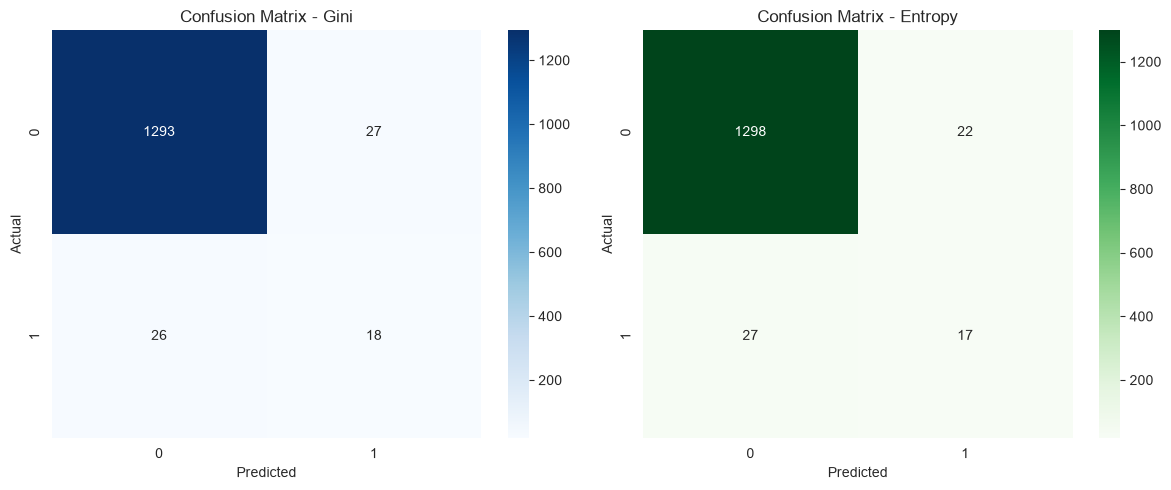

In [52]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
cm_gini    = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'], yticklabels=['0', '1'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Gini')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0', '1'], yticklabels=['0', '1'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Entropy')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [55]:
print("Gini:\n", cm_gini)
print("Entropy:\n", cm_entropy)

Gini:
 [[1293   27]
 [  26   18]]
Entropy:
 [[1298   22]
 [  27   17]]


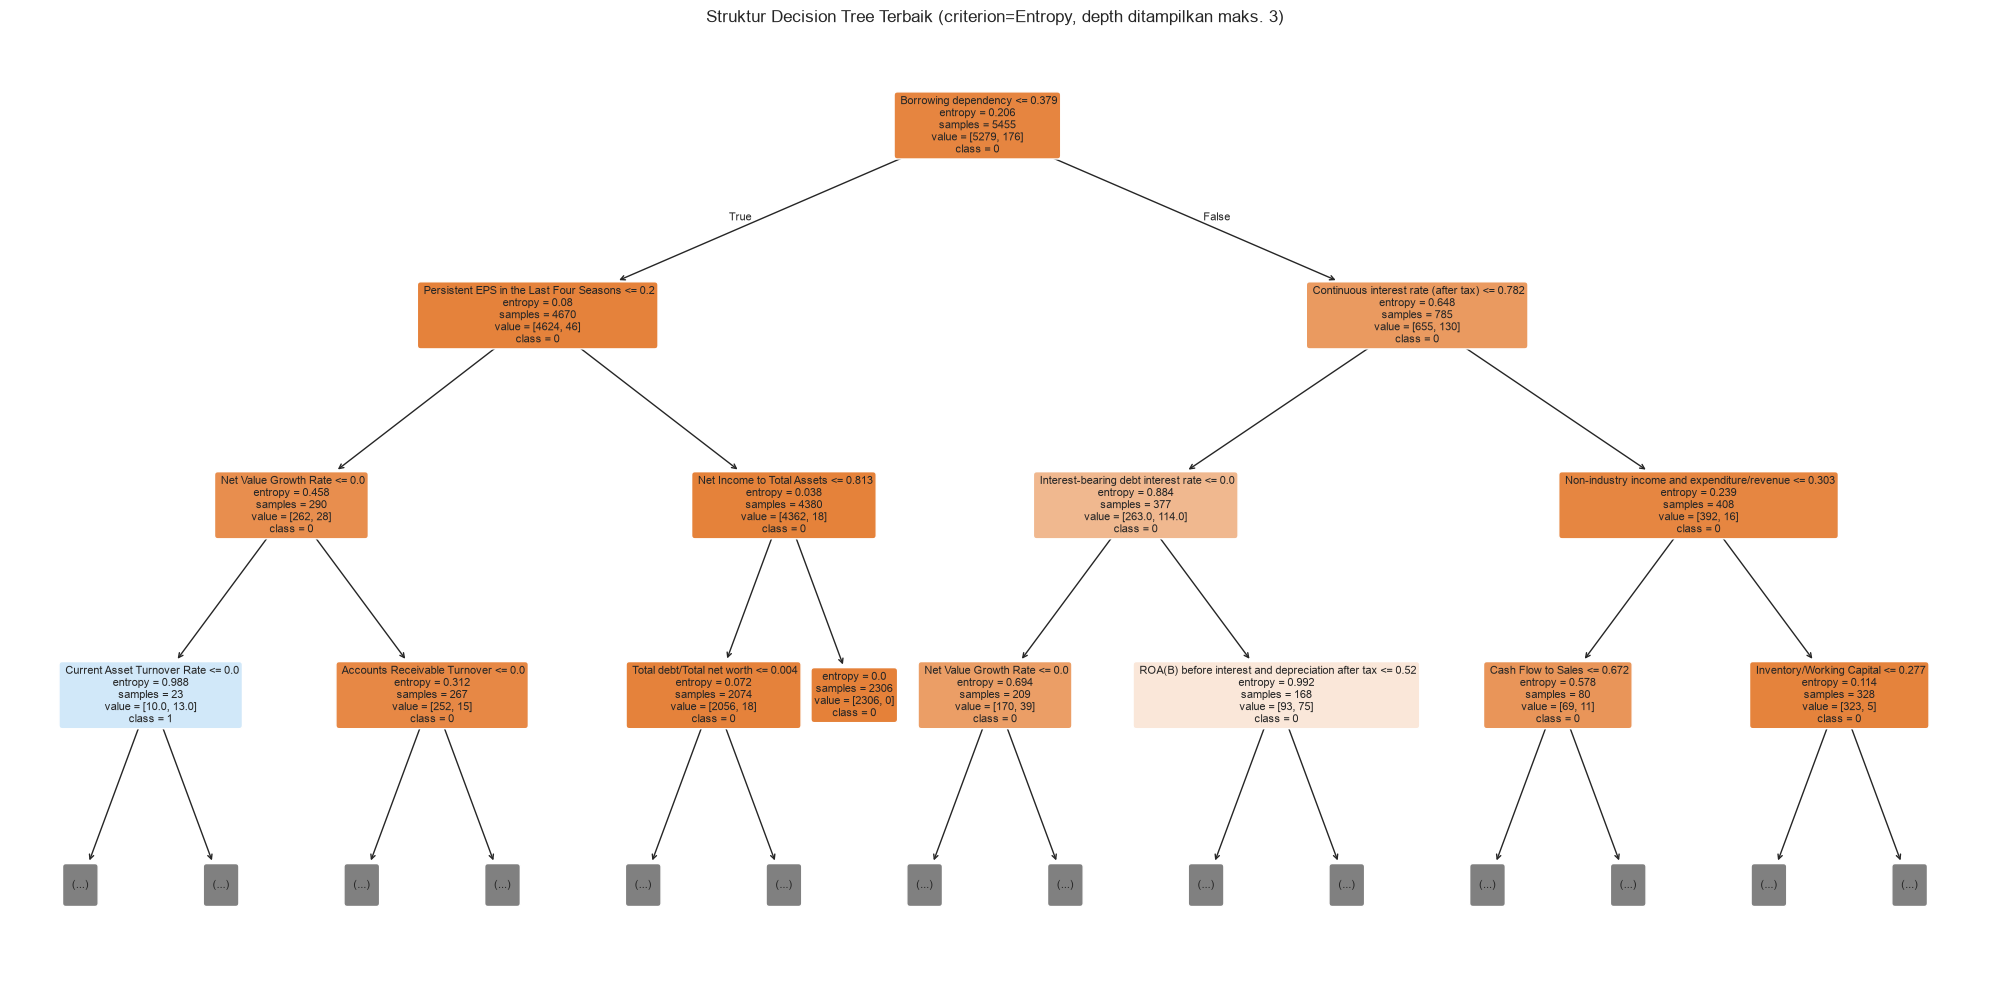

In [53]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

# Tentukan model terbaik berdasarkan F1-Score di test set
f1_gini    = f1_score(y_test, y_pred_gini,    zero_division=0)
f1_entropy = f1_score(y_test, y_pred_entropy, zero_division=0)

if f1_gini >= f1_entropy:
    model_terbaik = dt_gini
    nama_terbaik  = 'Gini'
    pred_terbaik  = y_pred_gini
else:
    model_terbaik = dt_entropy
    nama_terbaik  = 'Entropy'
    pred_terbaik  = y_pred_entropy

plt.figure(figsize=(20, 10))
plot_tree(
    model_terbaik,
    feature_names=X.columns,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title(f'Struktur Decision Tree Terbaik (criterion={nama_terbaik}, depth ditampilkan maks. 3)')
plt.tight_layout()
plt.show()

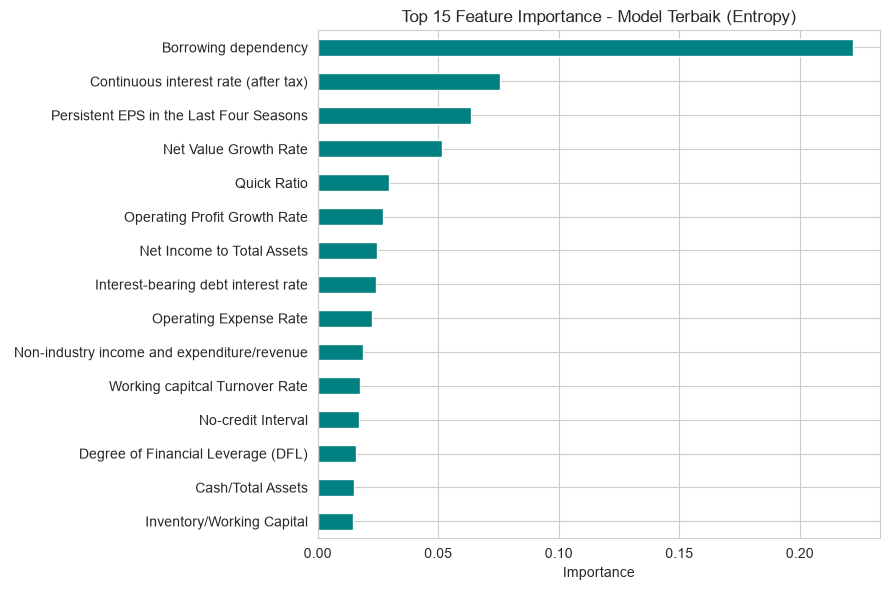

Borrowing dependency                           0.222147
Continuous interest rate (after tax)           0.075791
Persistent EPS in the Last Four Seasons        0.063519
Net Value Growth Rate                          0.051659
Quick Ratio                                    0.029765
Operating Profit Growth Rate                   0.026979
Net Income to Total Assets                     0.024663
Interest-bearing debt interest rate            0.024218
Operating Expense Rate                         0.022477
Non-industry income and expenditure/revenue    0.018859
Working capitcal Turnover Rate                 0.017671
No-credit Interval                             0.016993
Degree of Financial Leverage (DFL)             0.015759
Cash/Total Assets                              0.015094
Inventory/Working Capital                      0.014529
dtype: float64

In [54]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

# Ambil feature importance lalu urutkan descending
importance = pd.Series(
    model_terbaik.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Ambil top 15 fitur terpenting
top_importance = importance.head(15)

plt.figure(figsize=(9, 6))
top_importance.sort_values().plot(kind='barh', color='teal')
plt.title(f'Top 15 Feature Importance - Model Terbaik ({nama_terbaik})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_importance

In [56]:
# Distribusi kelas target 
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)

# Jumlah fitur & sampel
print("Jumlah fitur:", X.shape[1])
print("Jumlah sampel train:", X_train.shape[0])
print("Jumlah sampel test :", X_test.shape[0])

# Kedalaman tree tiap model (buat bahas kompleksitas)
print("Depth Gini    :", dt_gini.get_depth())
print("Depth Entropy :", dt_entropy.get_depth())
print("Jumlah leaf Gini    :", dt_gini.get_n_leaves())
print("Jumlah leaf Entropy :", dt_entropy.get_n_leaves())

Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64
Jumlah fitur: 95
Jumlah sampel train: 5455
Jumlah sampel test : 1364
Depth Gini    : 20
Depth Entropy : 17
Jumlah leaf Gini    : 124
Jumlah leaf Entropy : 99


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### 1. Perbandingan Kriteria Gini vs Entropy

Berdasarkan tabel metrik evaluasi pada test set:

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Decision Tree (Gini) | 0.9611 | 0.4000 | 0.4091 | 0.4045 |
| Decision Tree (Entropy) | 0.9641 | 0.4359 | 0.3864 | 0.4096 |

**Selisih performa antara Gini dan Entropy sangat tipis:**

- Accuracy berbeda hanya **0.0030** (0.30%) — Entropy sedikit lebih tinggi.
- F1-Score berbeda hanya **0.0051** (0.51%) — Entropy sedikit lebih tinggi.
- Precision: Entropy lebih tinggi (+0.0359), artinya Entropy lebih baik dalam menghindari *false positive*.
- Recall: Gini lebih tinggi (+0.0227), artinya Gini sedikit lebih baik dalam menangkap sampel kelas minoritas (kelas 1).

**Confusion matrix juga mencerminkan hal serupa:**

| Model | TN | FP | FN | TP |
|-------|----|----|----|----|
| Gini | 1293 | 27 | 26 | 18 |
| Entropy | 1298 | 22 | 27 | 17 |

Model Entropy berhasil menekan *false positive* lebih baik (22 vs 27), sedangkan Gini sedikit lebih unggul dalam menekan *false negative* (26 vs 27). Perbedaan ini sangat kecil dan bisa dibilang **hampir tidak signifikan secara praktis**.

**Mengapa hasilnya demikian?**

Secara teoritis, Gini Impurity dan Entropy sama-sama mengukur tingkat ketidakmurnian (*impurity*) pada sebuah node:

- **Gini** = 1 − Σpᵢ² (mengukur probabilitas salah klasifikasi)
- **Entropy** = −Σpᵢ log₂ pᵢ (mengukur ketidakpastian informasi)

Kedua fungsi ini bersifat **monotonik satu terhadap yang lain** dalam banyak kasus, sehingga node yang dipilih untuk split seringkali sama atau mirip. Akibatnya, pohon yang dihasilkan pun cenderung mirip strukturnya.

Perbedaan kecil yang muncul (depth Gini = 20 vs Entropy = 17, jumlah leaf 124 vs 99) menunjukkan bahwa Entropy cenderung menghasilkan pohon yang **sedikit lebih ringkas**, namun performanya tetap setara.

**Kesimpulan:** Untuk dataset ini, pilihan antara Gini dan Entropy **tidak menghasilkan perbedaan signifikan**. Gini bisa jadi pilihan default karena komputasinya lebih ringan (tanpa operasi logaritma).

---

### 2. Temuan dari Eksperimen Regularisasi (max_depth)

Tabel akurasi train vs test untuk setiap nilai `max_depth`:

| max_depth | Train Accuracy | Test Accuracy | Gap (Train − Test) |
|-----------|----------------|---------------|---------------------|
| 1 | 0.9677 | 0.9677 | 0.0000 |
| 2 | 0.9699 | 0.9699 | 0.0000 |
| 3 | 0.9723 | 0.9699 | 0.0024 |
| 5 | 0.9775 | 0.9685 | 0.0090 |
| 10 | 0.9947 | 0.9604 | 0.0343 |
| None | 1.0000 | 0.9611 | 0.0389 |

**Grafik akurasi training vs testing** memperlihatkan pola klasik overfitting:

1. **`max_depth = 1 dan 2` (underfitting ringan)**
   - Akurasi train dan test hampir identik (~0.967–0.970).
   - Model masih terlalu sederhana, belum menangkap pola kompleks.

2. **`max_depth = 3` (titik optimal)**
   - Test accuracy mencapai nilai tertinggi yaitu **0.9699**.
   - Gap train-test sangat kecil (0.0024) → model masih generalisasi dengan baik.

3. **`max_depth = 5` (mulai melandai)**
   - Train accuracy naik (0.9775), tapi test accuracy **turun** ke 0.9685.
   - Gap mulai melebar (0.0090) → tanda awal overfitting.

4. **`max_depth = 10` (overfitting jelas)**
   - Train accuracy melonjak ke **0.9947**, tapi test accuracy **turun signifikan** ke 0.9604.
   - Gap melebar jadi **0.0343**.

5. **`max_depth = None` (overfitting paling parah)**
   - Train accuracy sempurna **1.0000** (memorize training data).
   - Test accuracy justru **turun ke 0.9611**.
   - Gap tertinggi: **0.0389**.

**Ciri-ciri overfitting yang terlihat dari grafik:**

- **Garis train accuracy** terus naik mendekati 1.0 seiring bertambahnya `max_depth`.
- **Garis test accuracy** justru stagnan di sekitar 0.96 lalu **menurun** setelah `max_depth ≥ 5`.
- **Gap antara kedua garis** semakin melebar — inilah indikasi utama overfitting.

**Kesimpulan:** Model mulai menunjukkan gejala overfitting sejak **`max_depth = 5`**, dan semakin parah pada `max_depth = 10` dan `None`. Titik optimal untuk dataset ini adalah **`max_depth = 3`**, di mana test accuracy tertinggi dan gap train-test masih sangat kecil.

---

### 3. Fitur Paling Berpengaruh (Feature Importance)

Berdasarkan feature importance dari model terbaik, 10 fitur teratas adalah:

| Rank | Fitur | Importance |
|------|-------|------------|
| 1 | Borrowing dependency | 0.2221 |
| 2 | Continuous interest rate (after tax) | 0.0758 |
| 3 | Persistent EPS in the Last Four Seasons | 0.0635 |
| 4 | Net Value Growth Rate | 0.0517 |
| 5 | Quick Ratio | 0.0298 |
| 6 | Operating Profit Growth Rate | 0.0270 |
| 7 | Net Income to Total Assets | 0.0247 |
| 8 | Interest-bearing debt interest rate | 0.0242 |
| 9 | Operating Expense Rate | 0.0225 |
| 10 | Non-industry income and expenditure/revenue | 0.0189 |

**Interpretasi:**

- **`Borrowing dependency`** mendominasi dengan importance **0.2221** (22.21%) — jauh di atas fitur lain. Fitur ini mengukur seberapa besar perusahaan bergantung pada pinjaman. Wajar jika menjadi prediktor utama kebangkrutan, karena perusahaan dengan ketergantungan utang tinggi lebih rentan gagal bayar.

- **`Continuous interest rate (after tax)`** (7.58%) dan **`Interest-bearing debt interest rate`** (2.42%) juga terkait dengan beban bunga. Tingginya beban bunga relatif terhadap pendapatan merupakan sinyal kuat kesulitan keuangan.

- **`Persistent EPS in the Last Four Seasons`** (6.35%) mengukur konsistensi laba per saham. Perusahaan dengan EPS yang konsisten positif lebih kecil kemungkinannya bangkrut.

- **`Net Value Growth Rate`** (5.17%) dan **`Net Income to Total Assets`** (2.47%) berkaitan dengan profitabilitas dan pertumbuhan nilai perusahaan.

- **`Quick Ratio`** (2.98%) adalah rasio likuiditas jangka pendek — perusahaan dengan quick ratio rendah lebih rentan gagal bayar kewajiban jangka pendek.

**Kesimpulan:** Fitur-fitur yang paling berpengaruh didominasi oleh **indikator kesehatan finansial** — terutama yang berkaitan dengan **utang, beban bunga, profitabilitas, dan likuiditas**. Ini masuk akal secara domain: kebangkrutan perusahaan hampir selalu didahului oleh memburuknya rasio-rasio keuangan tersebut.

---

### 4. Catatan Tambahan: Dampak Class Imbalance

Dataset ini sangat **imbalanced**:
- Kelas 0 (tidak bangkrut): **6599 sampel (96.77%)**
- Kelas 1 (bangkrut): **220 sampel (3.23%)**

Implikasi pada evaluasi:

- **Accuracy menjadi metrik yang misleading.** Model yang selalu memprediksi kelas 0 akan mendapat akurasi ~96.77% tanpa benar-benar "belajar" apa pun.
- **Precision, Recall, dan F1-Score lebih relevan** untuk mengevaluasi performa pada kelas minoritas (kelas 1 = bangkrut).
- Nilai **Recall kelas 1 yang rendah** (~0.39–0.41) menunjukkan model masih melewatkan banyak perusahaan yang sebenarnya bangkrut (*false negative*).
- Nilai **Precision kelas 1 yang rendah** (~0.40–0.44) menunjukkan banyak *false positive* — perusahaan sehat yang diprediksi bangkrut.

Untuk perbaikan ke depan, disarankan menggunakan:
- `class_weight='balanced'` pada `DecisionTreeClassifier`
- Teknik resampling seperti **SMOTE** atau **undersampling**
- Threshold tuning pada probabilitas prediksi

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

## Kesimpulan

1. **Gini vs Entropy tidak berbeda signifikan.** Pada dataset ini, kedua kriteria menghasilkan performa yang hampir setara (F1-Score 0.4045 vs 0.4096). Perbedaannya terlalu kecil untuk dianggap penting, jadi Gini tetap bisa jadi pilihan default karena lebih ringan secara komputasi.

2. **Overfitting muncul saat `max_depth` terlalu besar.** Dari eksperimen, model mulai overfitting di `max_depth = 5` dan semakin parah di `max_depth = 10` serta `None`. Titik optimal ada di **`max_depth = 3`**, di mana akurasi test tertinggi (0.9699) dan gap train-test masih kecil.

3. **Fitur yang paling berpengaruh adalah `Borrowing dependency`** (importance 0.2221), disusul fitur-fitur lain yang berkaitan dengan utang, beban bunga, profitabilitas, dan likuiditas. Ini masuk akal karena kebangkrutan perusahaan biasanya memang didahului oleh memburuknya rasio-rasio keuangan tersebut.

4. **Dataset sangat imbalanced** (96.77% : 3.23%), sehingga accuracy saja kurang bisa diandalkan. Metrik F1-Score, Precision, dan Recall lebih relevan untuk menilai performa pada kelas minoritas.

## Saran

- **Coba `class_weight='balanced'`** atau teknik resampling (SMOTE / undersampling) untuk mengatasi imbalanced, karena recall kelas 1 masih rendah (~0.39–0.41).
- **Coba pruning dengan `ccp_alpha`** untuk menyederhanakan pohon tanpa harus mengatur `max_depth` manual.
- **Tuning hyperparameter lain** seperti `min_samples_split`, `min_samples_leaf`, atau `max_features` untuk hasil yang lebih stabil.
- **Bandingkan dengan model lain** seperti Random Forest atau XGBoost untuk melihat apakah ada peningkatan performa.
- **Gunakan cross-validation** (misal `StratifiedKFold`) agar hasil evaluasi lebih representatif, tidak bergantung pada satu kali split.